# Multi-omics patient stratification and biomarker discovery in CLL

**Integrating four omics layers to recover disease subtypes, identify biomarkers, and link molecular state to drug response.**

This notebook integrates genomics, transcriptomics, epigenomics, and drug-response data from a cohort of
200 chronic lymphocytic leukemia (CLL) patients, then uses the integrated representation for the core
tasks of translational analysis: patient stratification, biomarker discovery, and drug-response
association.

**Workflow:** four omics matrices to a shared low-dimensional representation (Multi-Omics Factor Analysis,
MOFA) to (i) biological validation against known prognostic markers, (ii) unsupervised patient
stratification, (iii) biomarker discovery from factor loadings, (iv) a drug-response biomarker, and
(v) a cross-validated predictive model for prognostic class.

**Data:** the CLL multi-omics cohort of Dietrich et al. (J. Clin. Invest. 2018), as distributed by the MOFA
project. Layers: gene expression (5,000 genes), DNA methylation (4,248 CpGs), somatic mutations and copy-
number alterations (69 features, including the prognostic markers IGHV and trisomy 12), and ex-vivo
response to 310 drug/concentration combinations. MOFA handles the substantial missingness across layers
natively.

*Author: Anmol Adhav*

In [1]:
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt
import rdata
from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from mofapy2.run.entry_point import entry_point
warnings.filterwarnings("ignore")

## 1. Load the four omics layers

Each layer is a matrix of features by patients over a shared set of 200 patients. We keep the feature and
sample names so the integrated factors can be traced back to genes, CpGs, mutations, and drugs.

In [2]:
URL = "https://raw.githubusercontent.com/bioFAM/MOFAdata/master/data/CLL_data.RData"
import urllib.request, os
os.makedirs("data", exist_ok=True)
path = "data/CLL_data.RData"
if not os.path.exists(path):
    urllib.request.urlretrieve(URL, path)

parsed = rdata.read_rda(path)["CLL_data"]
VIEWS = ["Drugs", "Methylation", "mRNA", "Mutations"]
raw = {k: np.asarray(parsed[k].values, dtype=float) for k in VIEWS}        # features x patients
feat_names = {k: [str(x) for x in parsed[k].coords["dim_0"].values] for k in VIEWS}
samples = [str(x) for x in parsed["mRNA"].coords["dim_1"].values]

overview = pd.DataFrame(
    {"features": [raw[v].shape[0] for v in VIEWS],
     "patients": [raw[v].shape[1] for v in VIEWS],
     "missing %": [round(100*np.isnan(raw[v]).mean(), 1) for v in VIEWS]},
    index=VIEWS)
print(overview.to_string()); print(f"\nShared patients: {len(samples)}")

             features  patients  missing %
Drugs             310       200        8.0
Methylation      4248       200        2.0
mRNA             5000       200       32.0
Mutations          69       200       33.8

Shared patients: 200


## 2. Integrate with MOFA

Multi-Omics Factor Analysis learns a small set of latent factors that explain variation shared across (and
specific to) the omics layers. It is an unsupervised, generative model: no clinical labels are used, and
missing values are handled within the model. The result is a patients-by-factors matrix `Z` plus, for each
layer, a features-by-factors weight matrix `W` that makes the factors interpretable.

In [3]:
data_mat = [[raw[v].T] for v in VIEWS]   # MOFA expects samples x features per view
ep = entry_point()
ep.set_data_options(scale_views=True)
ep.set_data_matrix(data_mat, views_names=VIEWS, samples_names=[samples])
ep.set_model_options(factors=10)
ep.set_train_options(iter=1000, convergence_mode="medium", seed=1, verbose=False)
ep.build(); ep.run()

Z = ep.model.getExpectations()["Z"]["E"]                      # patients x factors
W = [np.asarray(w["E"]) for w in ep.model.getExpectations()["W"]]   # per view: features x factors
K = Z.shape[1]
print(f"Latent factors: {Z.shape}")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Scaling views to unit variance...

Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Successfully loaded view='Drugs' group='group0' with N=200 samples and D=310 features...
Successfully loaded view='Methylation' group='group0' with N=200 samples and D=4248 features...
Successfully loaded view='mRNA' group='group0' with N=200 samples and D=5000 features...
Successfully loaded view='Mutations' group='group0' with N=200 samples and D=69 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (Drugs): gaussian
- View 1 (Methylation): gaussian
- View 2 (mRNA): gaussian
- View 3 (Mutations): bernoulli






######################################
## Training the model with seed 1 ##
######################################


ELBO before training: -12217641.66 



Iteration 1: time=0.22, ELBO=-2168643.48, deltaELBO=10048998.178 (82.24990109%), Factors=10


Iteration 2: time=0.22, ELBO=-2067493.90, deltaELBO=101149.583 (0.82789777%), Factors=10


...

Iteration 136: time=0.21, ELBO=-1951590.43, deltaELBO=6.488 (0.00005310%), Factors=10


Iteration 137: time=0.21, ELBO=-1951584.11, deltaELBO=6.319 (0.00005172%), Factors=10


Iteration 138: time=0.22, ELBO=-1951577.95, deltaELBO=6.156 (0.00005039%), Factors=10


Iteration 139: time=0.21, ELBO=-1951571.95, deltaELBO=6.000 (0.00004911%), Factors=10


Iteration 140: time=0.22, ELBO=-1951566.10, deltaELBO=5.852 (0.00004790%), Factors=10

Converged!



#######################
## Training finished ##
#######################


Latent factors: (200, 10)


## 3. Which layer drives which factor?

The variance each factor explains in each layer shows how the omics are wired together: some factors are
shared across layers, others are specific to one. This decomposition is the first thing a translational
analyst reads from an integration.

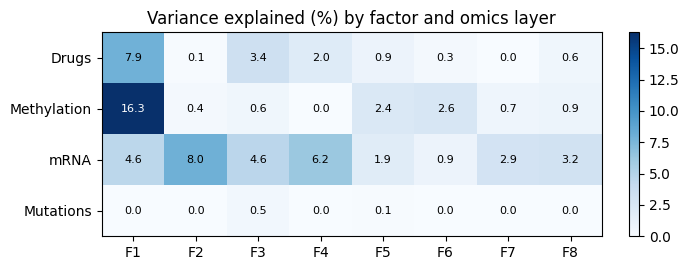

In [4]:
r2 = np.zeros((len(VIEWS), K))
for vi, v in enumerate(VIEWS):
    Y = raw[v].T.astype(float)
    Y = Y - np.nanmean(Y, axis=0, keepdims=True)
    sd = np.nanstd(Y, axis=0, keepdims=True); sd[sd == 0] = 1; Y /= sd
    mask = ~np.isnan(Y); tot = (np.where(mask, Y, 0.0) ** 2).sum()
    for k in range(K):
        res = np.where(mask, Y - np.outer(Z[:, k], W[vi][:, k]), 0.0)
        r2[vi, k] = max(0.0, 1 - (res ** 2).sum() / tot)
r2pct = 100 * r2

fig, ax = plt.subplots(figsize=(7, 2.8))
im = ax.imshow(r2pct[:, :8], cmap="Blues", aspect="auto")
ax.set_xticks(range(8)); ax.set_xticklabels([f"F{i+1}" for i in range(8)])
ax.set_yticks(range(len(VIEWS))); ax.set_yticklabels(VIEWS)
for i in range(len(VIEWS)):
    for j in range(8):
        ax.text(j, i, f"{r2pct[i,j]:.1f}", ha="center", va="center",
                fontsize=8, color="black" if r2pct[i,j] < r2pct.max()*0.6 else "white")
ax.set_title("Variance explained (%) by factor and omics layer")
plt.colorbar(im, ax=ax, fraction=0.025); plt.tight_layout(); plt.show()

## 4. Biological validation: do the factors recover known biology?

A useful integration should rediscover established disease axes without being told about them. CLL has two
dominant molecular markers: **IGHV mutation status** (the strongest prognostic factor) and **trisomy 12**.
We check whether any unsupervised factor aligns with each.

IGHV       aligns with Factor 1:  r = -0.86,  p = 9.1e-56
trisomy12  aligns with Factor 3:  r = +0.75,  p = 1.1e-35


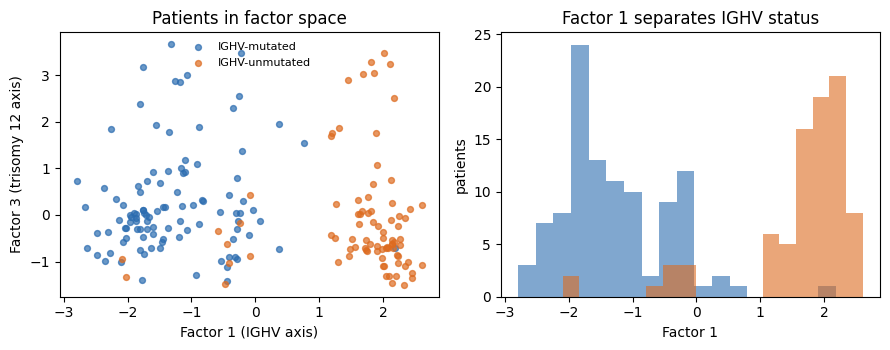

In [5]:
def marker(name): return np.asarray(parsed["Mutations"].sel(dim_0=name).values, dtype=float)

results = {}
for mk in ["IGHV", "trisomy12"]:
    y = marker(mk); m = ~np.isnan(y)
    best = max(range(K), key=lambda k: abs(pearsonr(Z[m, k], y[m])[0]))
    r, p = pearsonr(Z[m, best], y[m]); results[mk] = best
    print(f"{mk:10s} aligns with Factor {best+1}:  r = {r:+.2f},  p = {p:.1e}")

fI, fT = results["IGHV"], results["trisomy12"]
ighv = marker("IGHV")
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
for grp, col, lbl in [(1, "#2b6cb0", "IGHV-mutated"), (0, "#dd6b20", "IGHV-unmutated")]:
    s = ighv == grp
    ax[0].scatter(Z[s, fI], Z[s, fT], s=18, alpha=0.7, color=col, label=lbl)
ax[0].set_xlabel(f"Factor {fI+1} (IGHV axis)"); ax[0].set_ylabel(f"Factor {fT+1} (trisomy 12 axis)")
ax[0].legend(frameon=False, fontsize=8); ax[0].set_title("Patients in factor space")
for grp, col in [(1, "#2b6cb0"), (0, "#dd6b20")]:
    ax[1].hist(Z[ighv == grp, fI], bins=18, alpha=0.6, color=col)
ax[1].set_xlabel(f"Factor {fI+1}"); ax[1].set_ylabel("patients"); ax[1].set_title("Factor 1 separates IGHV status")
plt.tight_layout(); plt.show()

## 5. Patient stratification

Clustering patients on the top factors yields molecular subgroups. We then read off their composition by
IGHV status to confirm the subgroups are clinically meaningful rather than arbitrary.

           n  IGHV_mutated_frac
subgroup                       
0         76               0.94
1         60               0.67
2         64               0.02


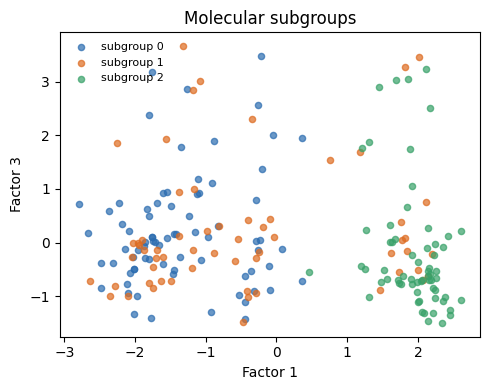

In [6]:
lab = KMeans(n_clusters=3, random_state=0, n_init=10).fit_predict(Z[:, :4])
strat = pd.DataFrame({"subgroup": lab, "IGHV": ighv})
summary = strat.groupby("subgroup").agg(n=("IGHV", "size"),
                                        IGHV_mutated_frac=("IGHV", "mean")).round(2)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
for cl, col in zip(sorted(set(lab)), ["#2b6cb0", "#dd6b20", "#38a169"]):
    s = lab == cl
    ax.scatter(Z[s, fI], Z[s, fT], s=20, alpha=0.7, color=col, label=f"subgroup {cl}")
ax.set_xlabel(f"Factor {fI+1}"); ax.set_ylabel(f"Factor {fT+1}")
ax.legend(frameon=False, fontsize=8); ax.set_title("Molecular subgroups"); plt.tight_layout(); plt.show()

## 6. Biomarker discovery from factor loadings

The weights `W` rank how strongly each feature contributes to a factor. Reading the top loadings on the
IGHV axis surfaces candidate transcriptional and drug-response biomarkers for that disease axis. (Genes are
Ensembl IDs and drugs are coded identifiers in this public release; both map to named entities in the
study's companion annotation.)

In [7]:
for v in ["mRNA", "Drugs"]:
    vi = VIEWS.index(v); w = W[vi][:, fI]
    top = np.argsort(-np.abs(w))[:8]
    print(f"Top {v} loadings on Factor {fI+1}:")
    for i in top:
        print(f"   {feat_names[v][i]:18s}  {w[i]:+.2f}")
    print()

Top mRNA loadings on Factor 1:
   ENSG00000186522     +1.10
   ENSG00000198046     +1.09
   ENSG00000198142     +1.07
   ENSG00000196263     +1.02
   ENSG00000175445     +0.96
   ENSG00000182195     +0.88
   ENSG00000168594     -0.86
   ENSG00000154655     +0.85

Top Drugs loadings on Factor 1:
   D_078_3             -0.84
   D_020_2             -0.81
   D_017_1             -0.73
   D_050_2             -0.70
   D_017_2             -0.69
   D_020_3             -0.69
   D_078_2             -0.67
   D_017_3             -0.67



## 7. A drug-response biomarker

Correlating ex-vivo drug response with the IGHV factor identifies compounds whose activity tracks the
molecular axis, that is, candidate response biomarkers of the kind used for patient stratification in
trials.

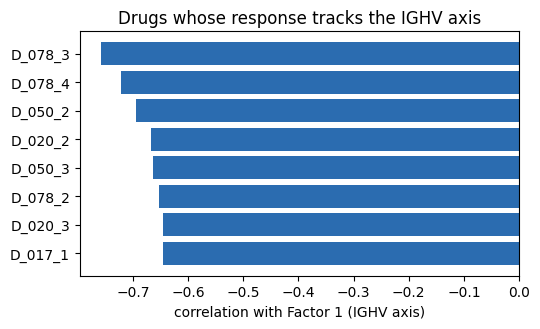

In [8]:
drugs = raw["Drugs"].T
cors = []
for j in range(drugs.shape[1]):
    m = ~np.isnan(drugs[:, j])
    if m.sum() > 50:
        cors.append((feat_names["Drugs"][j], pearsonr(Z[m, fI], drugs[m, j])[0]))
cors.sort(key=lambda t: -abs(t[1]))
top = cors[:8]
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.barh([t[0] for t in top][::-1], [t[1] for t in top][::-1], color="#2b6cb0")
ax.set_xlabel(f"correlation with Factor {fI+1} (IGHV axis)")
ax.set_title("Drugs whose response tracks the IGHV axis"); plt.tight_layout(); plt.show()

## 8. Predictive model: prognostic class from gene expression

Finally, a supervised, cross-validated model predicting IGHV status directly from the transcriptome, an
expression-signature biomarker. Evaluation is 5-fold stratified ROC-AUC, which measures how well the
signature separates the two prognostic groups.

In [9]:
y = marker("IGHV"); m = ~np.isnan(y)
X = StandardScaler().fit_transform(SimpleImputer(strategy="mean").fit_transform(raw["mRNA"].T[m]))
clf = LogisticRegression(penalty="l2", C=0.1, max_iter=2000)
auc = cross_val_score(clf, X, y[m], cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc")
print(f"Predict IGHV status from gene expression")
print(f"5-fold CV ROC-AUC = {auc.mean():.3f} +/- {auc.std():.3f}")

Predict IGHV status from gene expression
5-fold CV ROC-AUC = 0.902 +/- 0.048


## 9. Adapt to your own multi-omics cohort (TCGA / cBioPortal)

The workflow is data-agnostic. Build a dictionary of `{layer_name: DataFrame (features x patients)}` over a
shared patient set and re-run from the MOFA step. For public cancer cohorts:

- **TCGA via cBioPortal:** the `bravado`/`cbio_py` clients, or a direct download from the data hub, give
  expression, methylation, mutation, and copy-number matrices per study (for example `brca_tcga_pan_can_atlas`).
- **TCGA via the GDC:** the `gdc-client` or the TCGAbiolinks workflow exports the same layers.
- **Recount3 / GEO:** for transcriptomics-only or paired designs.

After assembling the layers, align them on common sample IDs, keep the most variable features per layer to
control dimensionality, and feed them to the same `entry_point` call. The validation, stratification,
loading, and prediction cells then apply unchanged with your cohort's clinical variables in place of IGHV.

## Summary

Unsupervised integration of four omics layers recovers the two dominant molecular axes of CLL without using
any labels: **Factor 1 aligns with IGHV status (r = -0.86)** and another factor with **trisomy 12
(r = +0.75)**. Clustering on the factors yields molecular subgroups that separate cleanly by IGHV, the
factor loadings nominate transcriptional and drug-response biomarkers for the IGHV axis, and a cross-
validated expression signature predicts prognostic class at **ROC-AUC ~ 0.90**. The same pipeline transfers
directly to TCGA or other cohorts, supporting patient stratification, biomarker discovery, and drug-response
analysis from integrated multi-omics data.